# Session 07b — Stricter (scale-only) GFP⁺ + k-NN / density-ratio scale

**Verdict: FAIL.** This notebook walks through the hypothesis, the
evidence against it, and what comes next.

**Hypothesis.** The HCR GFP⁺ set used by sessions 06/07 includes too many
false positives from the rightmost-component tail of `log(feature)`. A
stricter cutoff at the Bayes-optimal intersection between the rightmost
and second-rightmost GMM components deflates that tail. If the stricter
set becomes a subject- and depth-independent subsample of the truth
population (matched HCR + unmatched CZ mapped into HCR), then:
- **M1:** per-axis k-NN distance ratio recovers `(sxy, sz)`.
- **M3:** global xy/z span ratio (each cloud uses its own native AABB)
  recovers `(sxy, sz)`.

**Scoring.** Landmark-Procrustes GT, ±5 % on both axes on at least one of
M1/M3, all 6 subjects.

**Result.**
- GMM sanity: **5/6** (767022 degenerate).
- Depth-density uniformity gate (CV ≤ 0.20, integrated ∈ [0.8, 1.25]): **0/5**.
- Scale ±5 % both-axes via M1 or M3: **0/5**.

Root cause: the residual per-subject, depth-dependent bias in HCR GFP⁺
(even at the strict threshold) is larger than the scale effect we want
to measure.


In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, '/root/capsule/code/dev_code')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

SESSION = Path('/root/capsule/code/sessions/07b_scale_clean_gfp')
with open(SESSION / 'results.json') as f:
    R = json.load(f)
summary = R['summary']
print(f"sanity={summary['n_sanity_passed']}/6  "
      f"depth-gate={summary['n_depth_gate_passed']}/6  "
      f"scale-pass5={summary['n_scale_pass5']}/6  "
      f"pass_6of6={summary['pass_6of6']}")
print('synthetic:', summary['synthetic'])


sanity=5/6  depth-gate=0/6  scale-pass5=0/6  pass_6of6=False
synthetic: {'sxy_expected': 1.77, 'sz_expected': 2.82, 'm1': {'sxy': 1.8041310454345691, 'sz': 2.8488693045901567}, 'm3': {'sxy': 1.77, 'sz': 2.82}}


## 1. GMM-intersection threshold

Code: `dev_code/07b_gfp_intersection_threshold.py`.

**Spot subjects (788406, 790322, 767018, 782149).** GMM-4 on
`log(density > 0)`. Rightmost component = K−1, next = K−2. Intersection
via closed-form quadratic.

**Intensity subjects (755252, 767022).** GMM-2 on `log10(mean − bg > 0)`.
Intersection in log10 domain → `10^x` linear cutoff.

**Sanity gate per subject.** (a) intersection strictly between the two
component means, (b) `n_strict ≥ 300`, (c) coreg coverage ≥ 0.80. A
failing subject is skipped downstream — it cannot contribute to the 6/6
target regardless.


In [2]:
rows = R['gmm_intersection']
df = pd.DataFrame([{
    'subject': r['subject'],
    'cutoff_strict': r['cutoff_linear'],
    'cutoff_v2.2': r['cutoff_v22_linear'],
    'n_strict': r['n_strict'],
    'n_v2.2': r['n_v22'],
    'coreg_cov': r['coreg_coverage_strict'],
    'sanity': 'OK' if r['sanity_passed'] else '/'.join(r['sanity_notes']),
} for r in rows])
df


,subject,cutoff_strict,cutoff_v2.2,n_strict,n_v2.2,coreg_cov,sanity
0,755252,34.596354,20.749210,19919,30804,0.901408,OK
1,767018,0.001080,0.000800,7903,9161,0.978022,OK
2,767022,10.615132,28.431780,28574,14239,0.982346,intersection outside top-two mean bracket
3,782149,0.001706,0.001339,3450,3831,0.966997,OK
4,788406,0.001092,0.000673,12508,17427,0.963151,OK
5,790322,0.001795,0.001512,9459,10131,0.962725,OK


755252


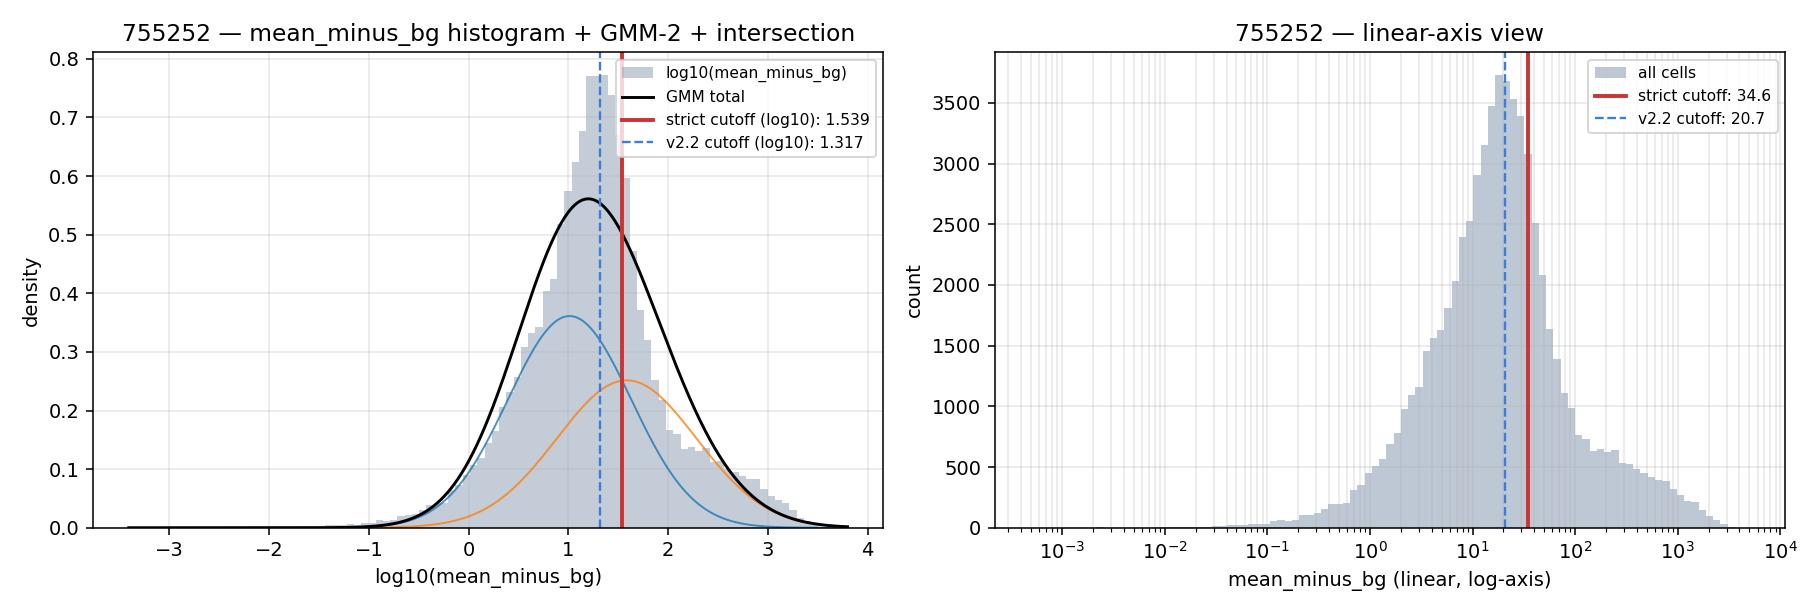

767018


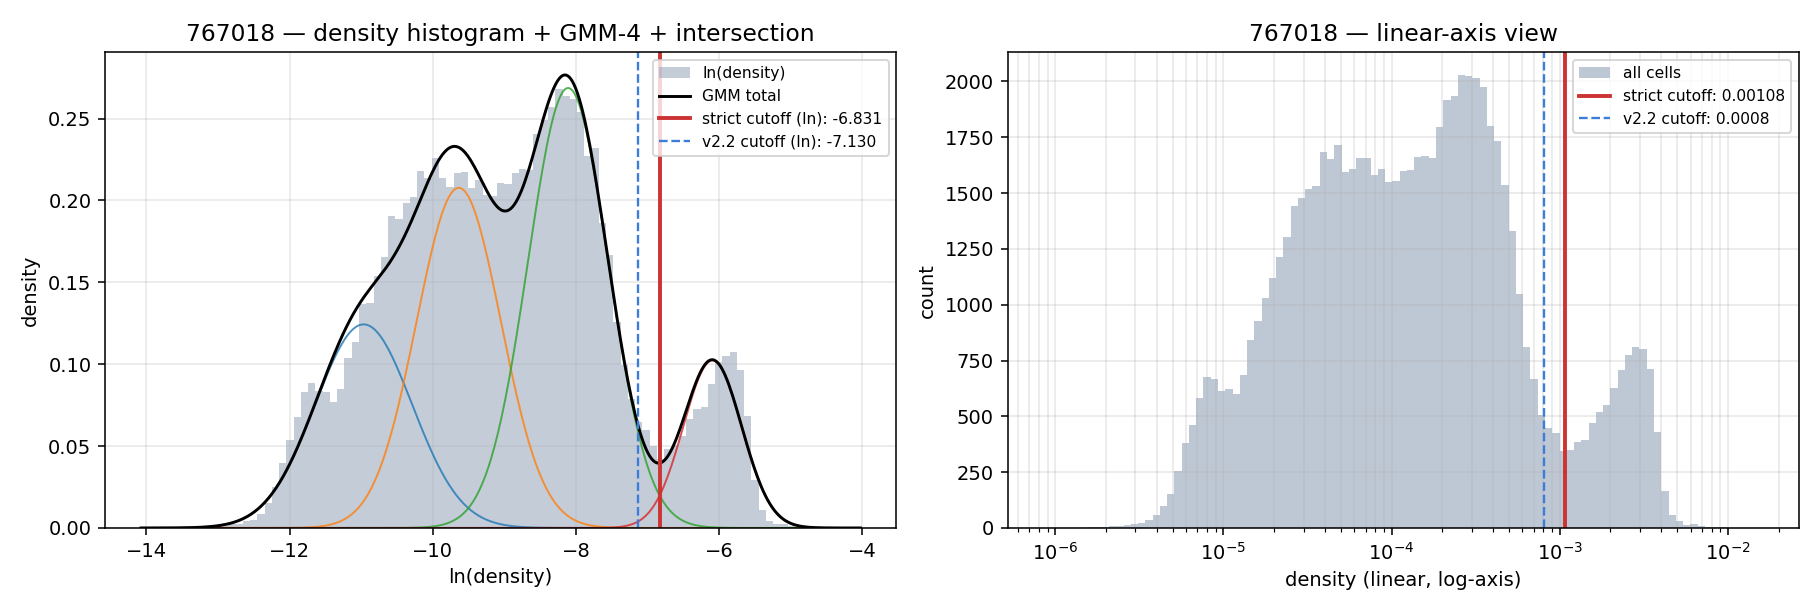

767022


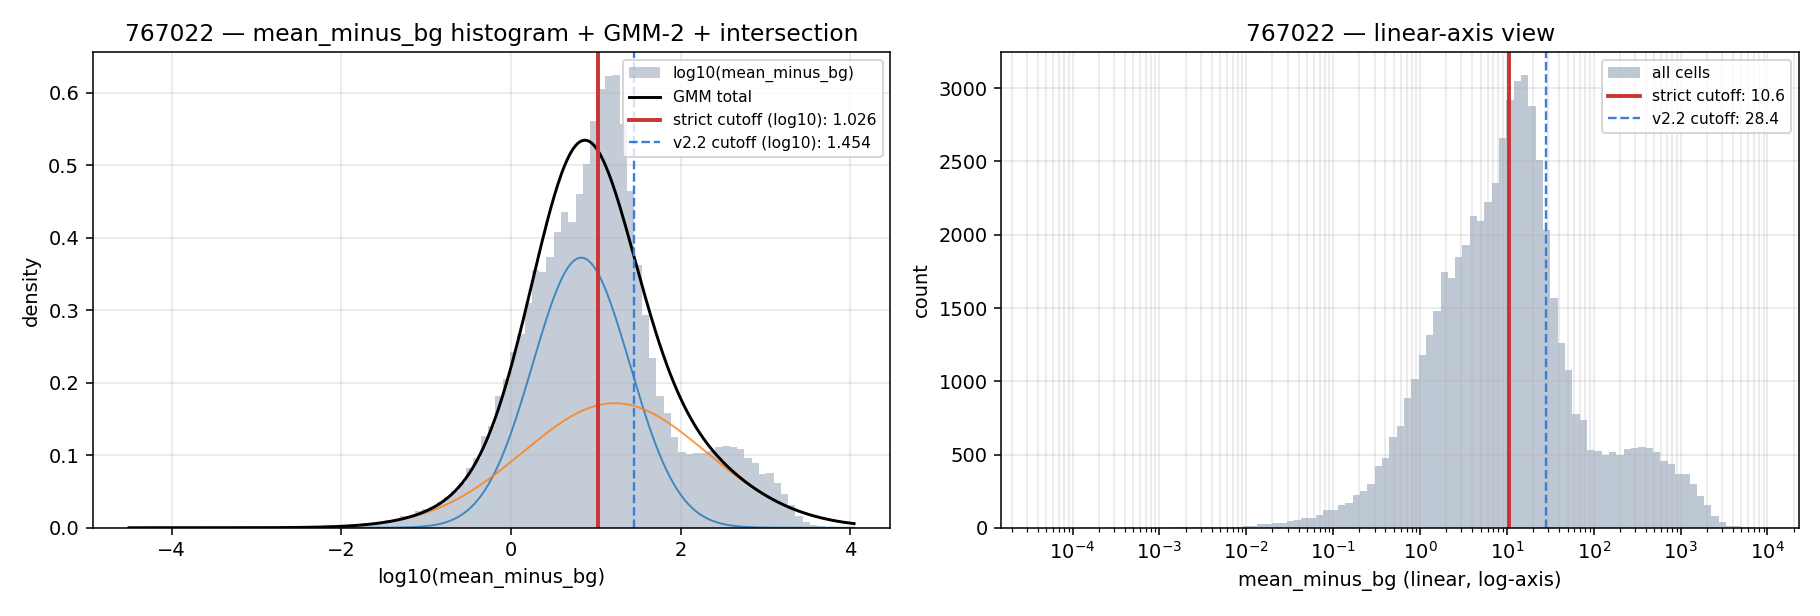

782149


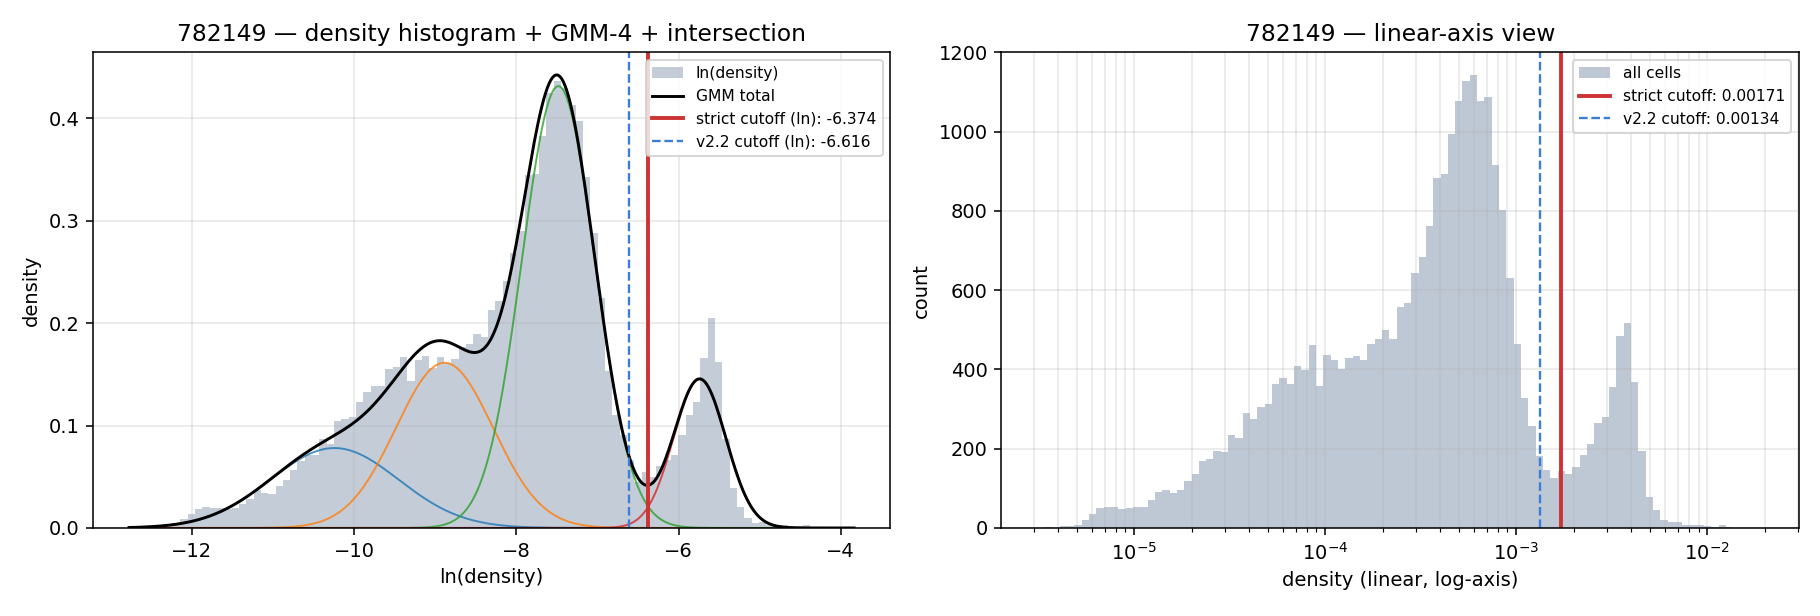

788406


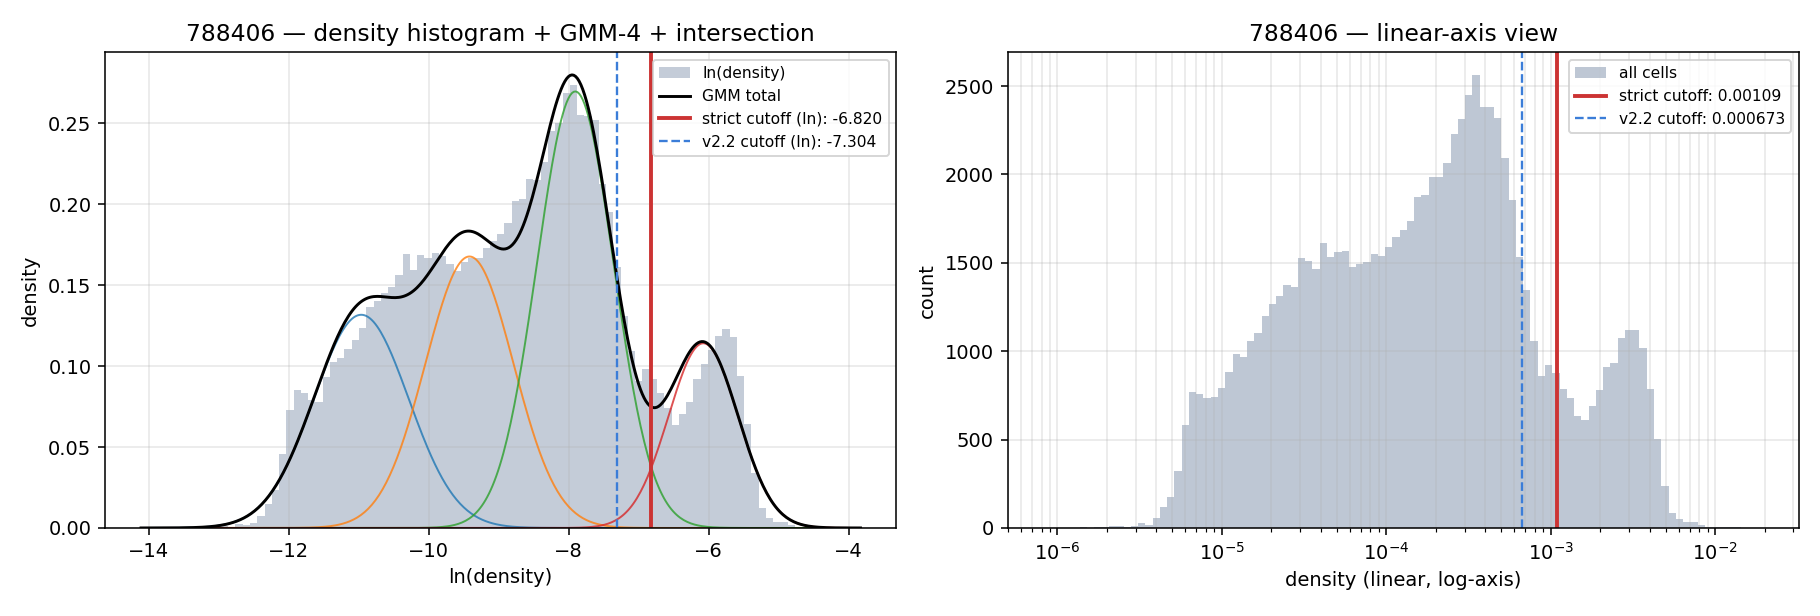

790322


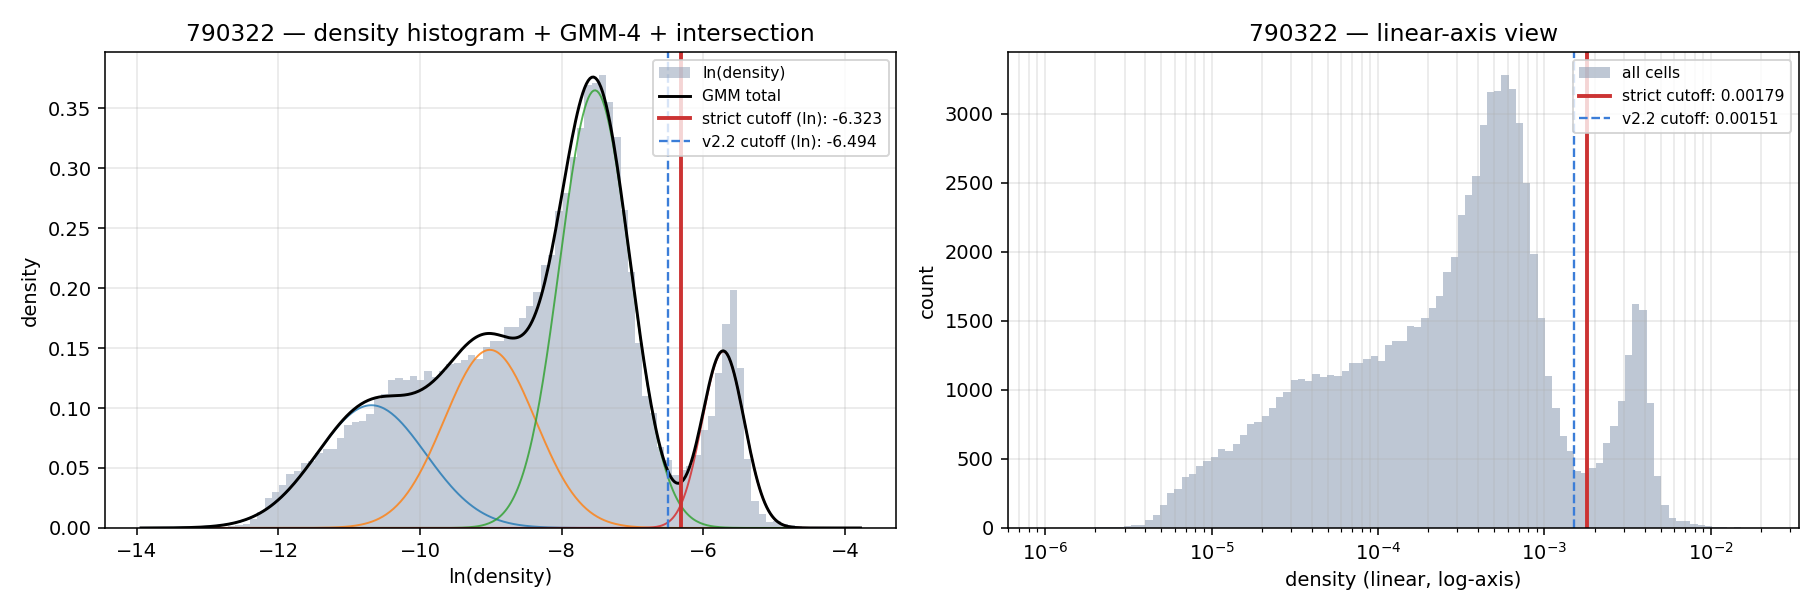

In [3]:
for sid in ['755252', '767018', '767022', '782149', '788406', '790322']:
    print(sid)
    display(Image(str(SESSION / 'figures' / f'gmm_threshold_{sid}.png')))


**767022 failure.** GMM-2 fits a narrow left component (σ=0.57, μ=0.83)
and a very wide right component (σ=1.08, μ=1.22). The two Gaussians don't
cross between their means; both roots of the quadratic fall outside
`[μ₁, μ₂]`. The midpoint fallback (linear cutoff 10.6) is *lower* than
the v2.2 threshold (28.4) — the strict set is *larger* than v2.2. This is
the weakest-assumption failure mode flagged in the pre-run critique.


## 2. Depth-density gate (strict vs v2.2)

Code: `dev_code/07_depth_density_diagnosis.py`, monkey-patched in the
driver to read the strict-GFP⁺ subject data. The truth baseline is
**matched HCR + unmatched CZ mapped into the HCR frame** — this is the
best depth-density proxy we have for the true underlying cell population.

**Gate A (per-bin uniformity).** CV of per-bin `GFP⁺/truth` ratio over
bins where `ρ_truth > p25` ≤ **0.20**.

**Gate B (cross-subject offset).** Integrated `GFP⁺/truth` ∈ [0.8, 1.25].


In [4]:
gates = R['depth_density_gate']
rows = []
for sid, g in gates.items():
    rows.append({
        'subject': sid,
        'cv_per_bin': g['per_bin_cv'],
        'integrated': g['integrated_ratio'],
        'gate_A_uniformity': g['gate_a_uniformity'],
        'gate_B_offset': g['gate_b_offset'],
        'pass': g['passed'],
    })
pd.DataFrame(rows).sort_values('subject')


,subject,cv_per_bin,integrated,gate_A_uniformity,gate_B_offset,pass
0,755252,0.405268,4.753245,False,False,False
1,767018,0.494492,1.106415,False,True,False
2,782149,1.093203,0.413110,False,False,False
3,788406,0.365722,2.417670,False,False,False
4,790322,0.349323,0.933627,False,True,False


755252  —  strict-GFP+ (top row) vs v2.2-GFP+ (session 07 figure, bottom row)


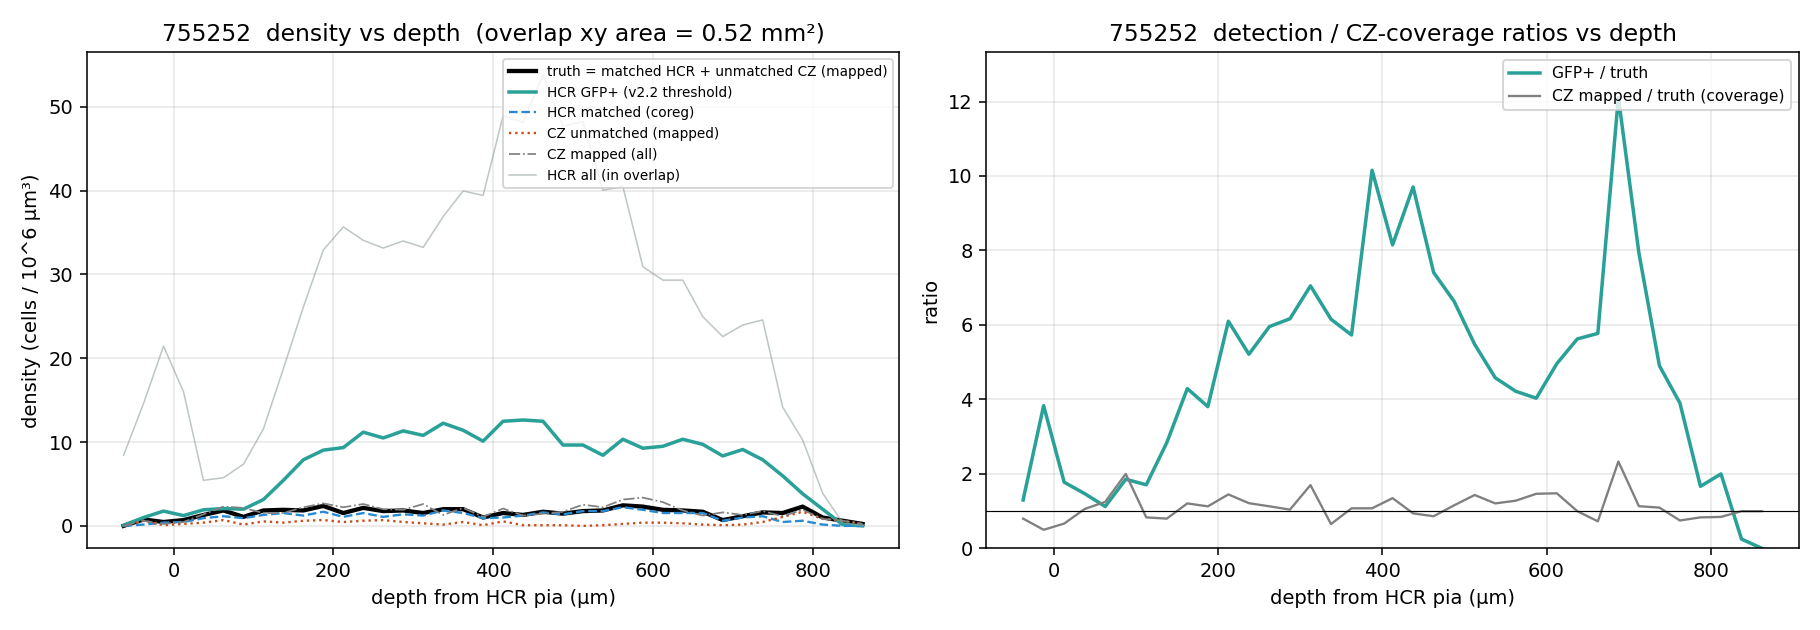

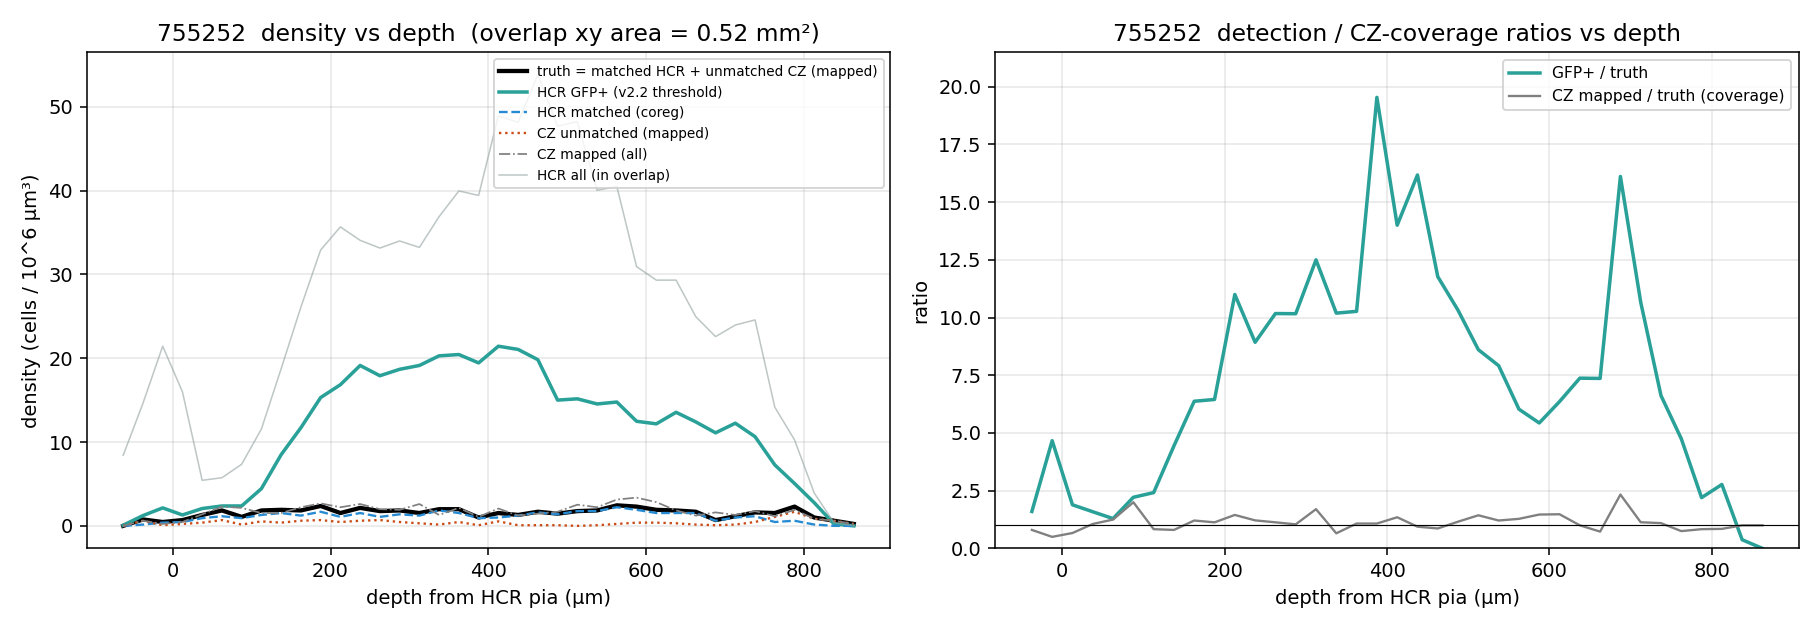

767018  —  strict-GFP+ (top row) vs v2.2-GFP+ (session 07 figure, bottom row)


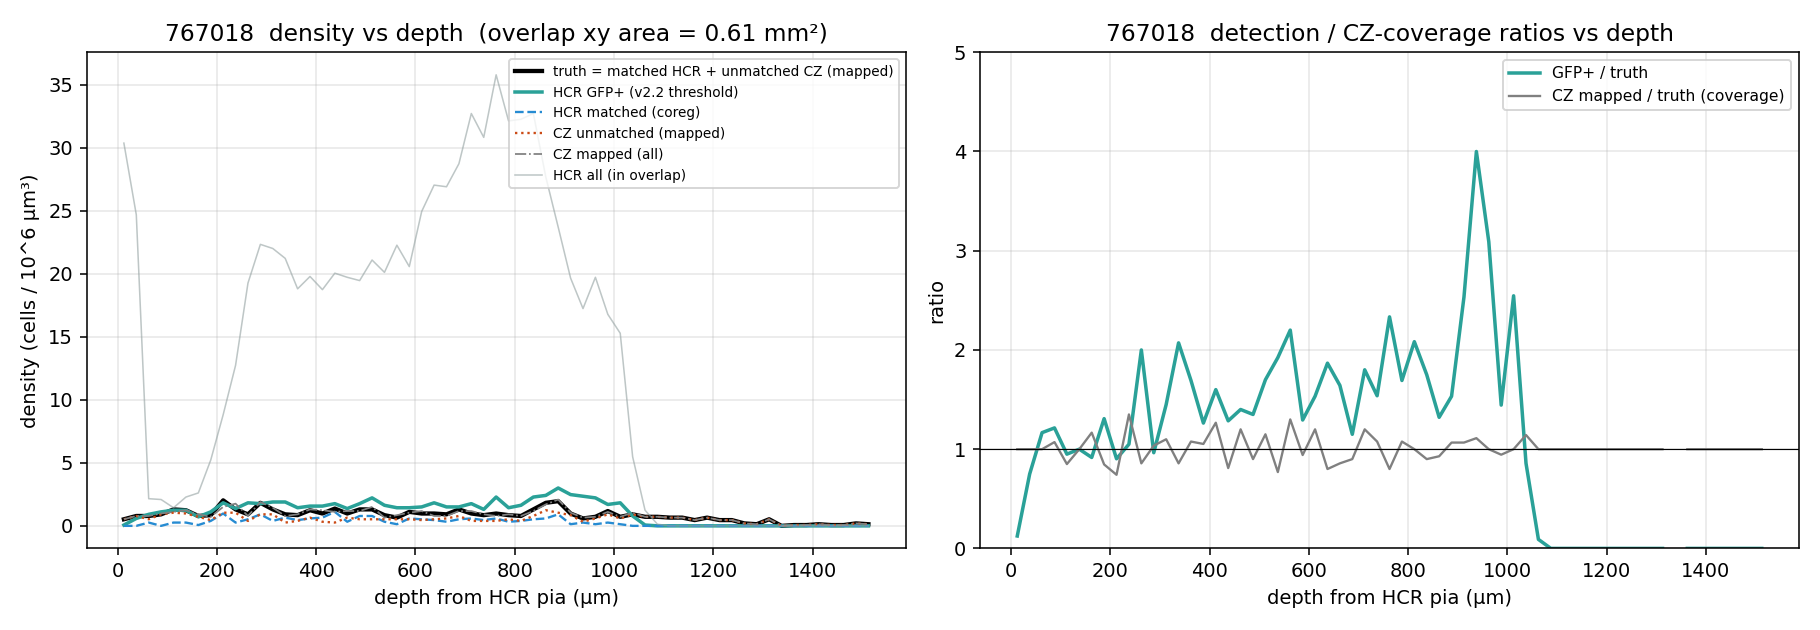

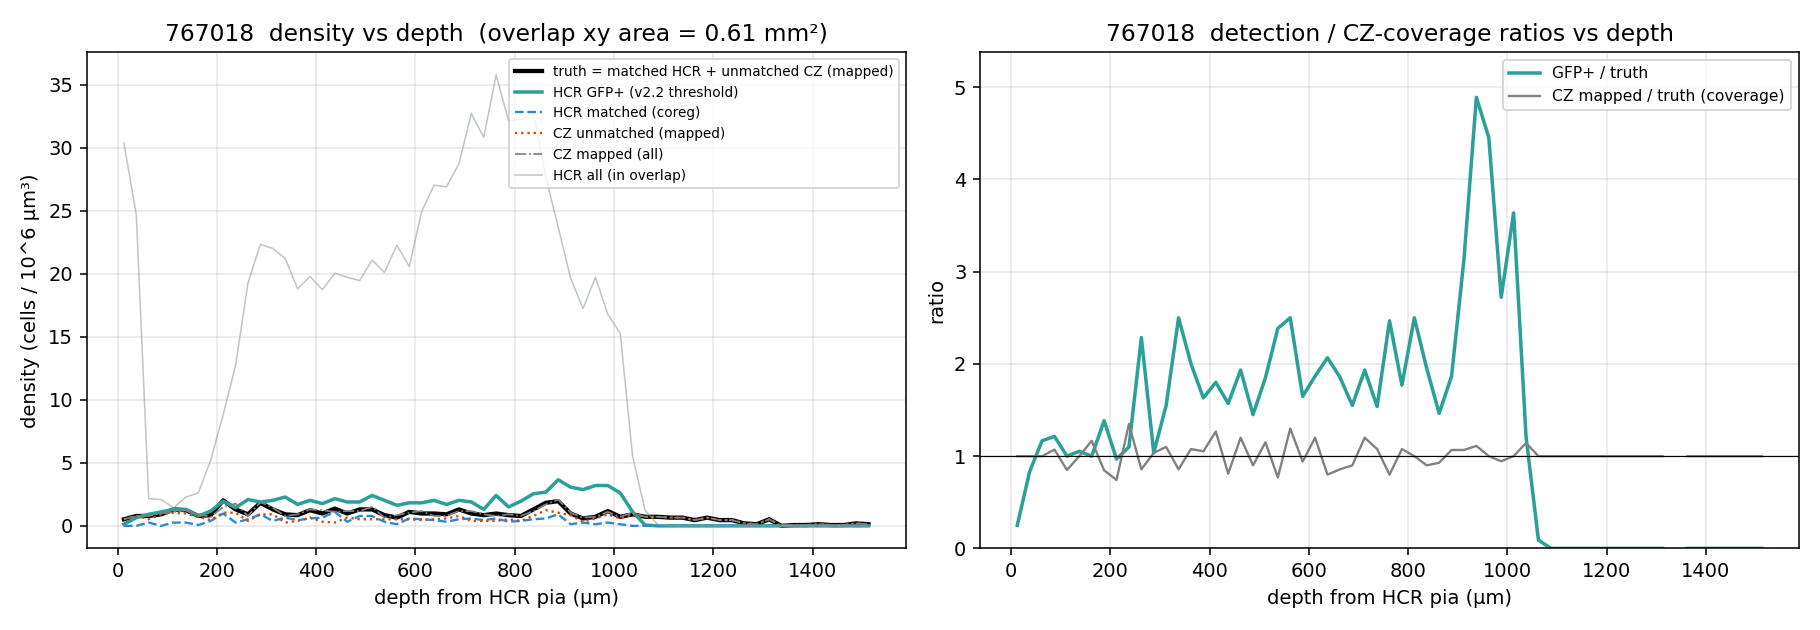

782149  —  strict-GFP+ (top row) vs v2.2-GFP+ (session 07 figure, bottom row)


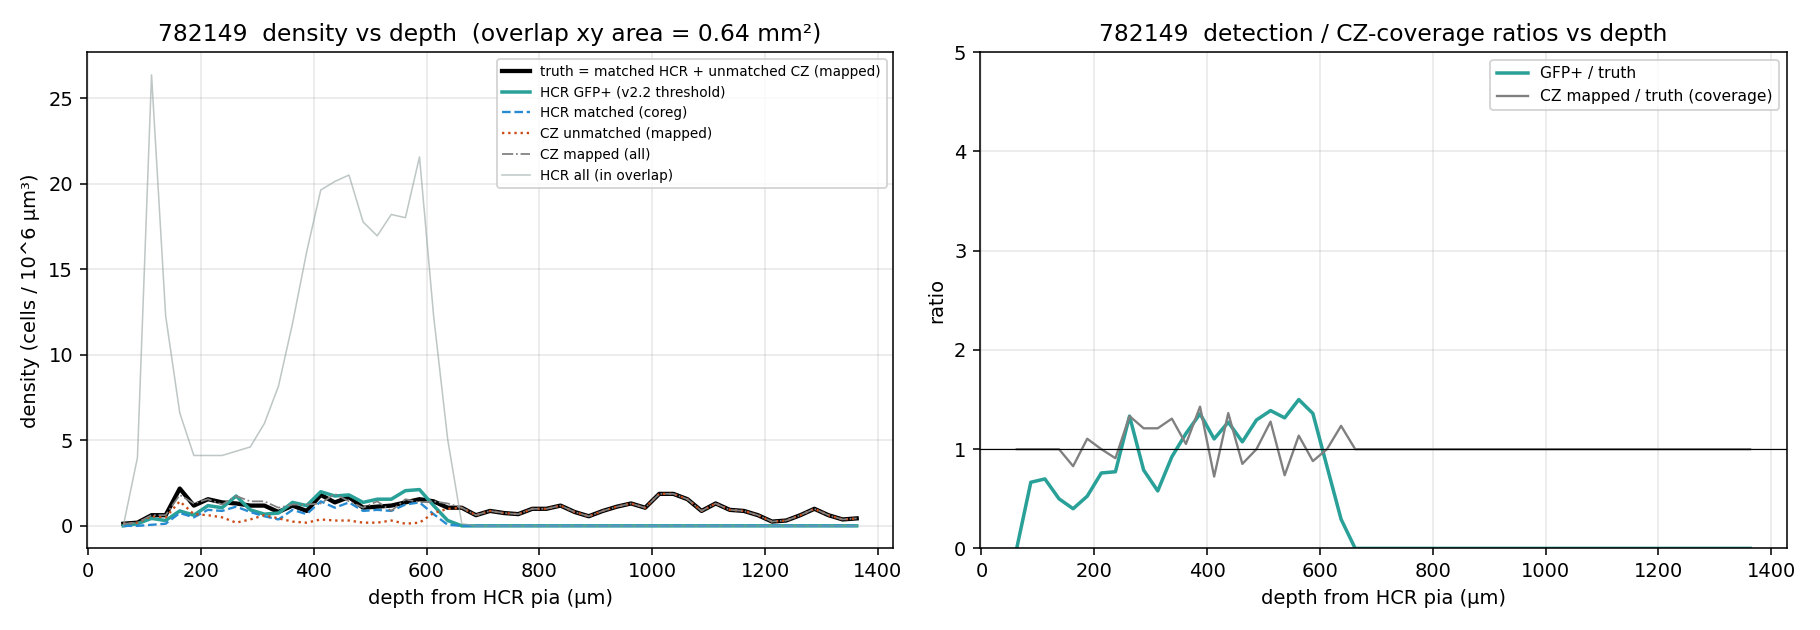

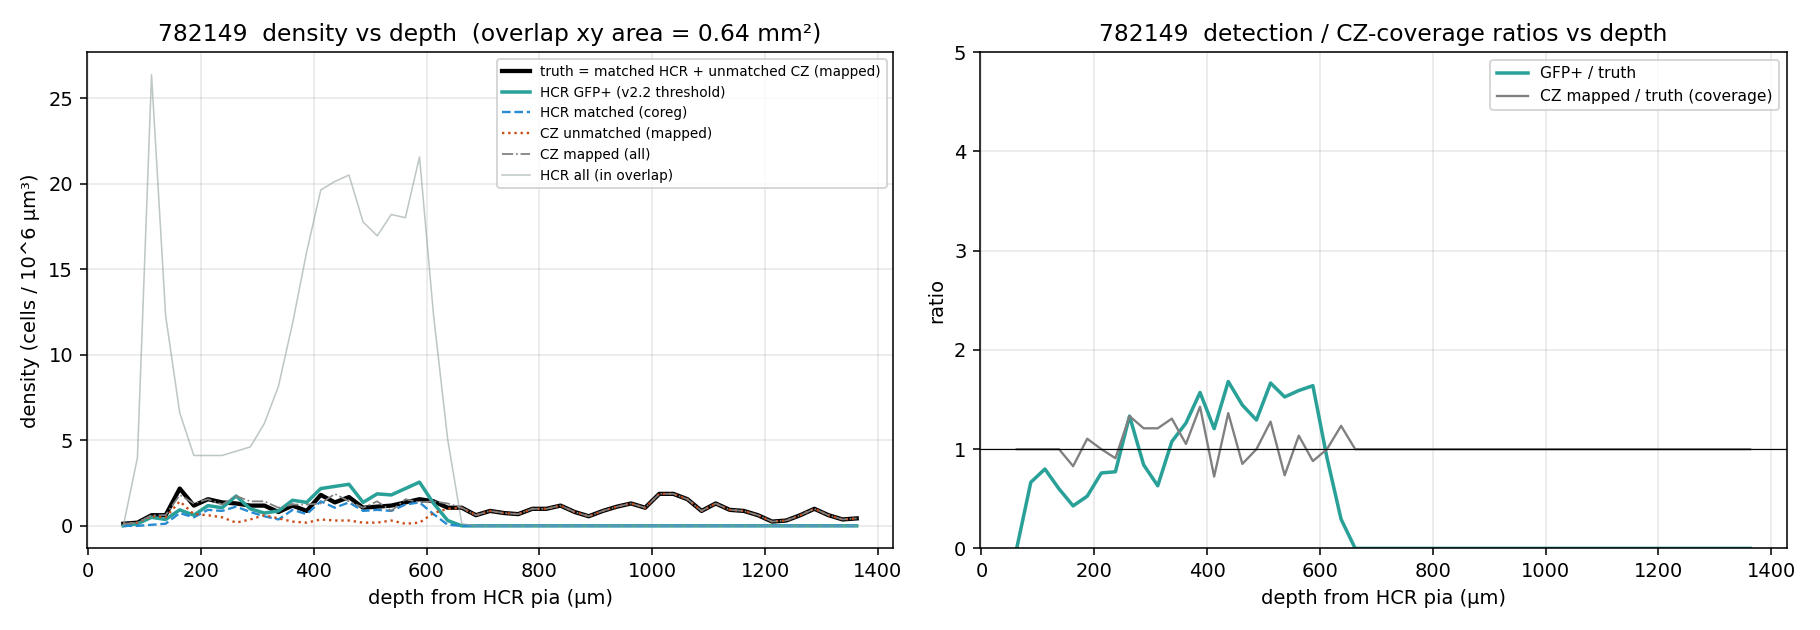

788406  —  strict-GFP+ (top row) vs v2.2-GFP+ (session 07 figure, bottom row)


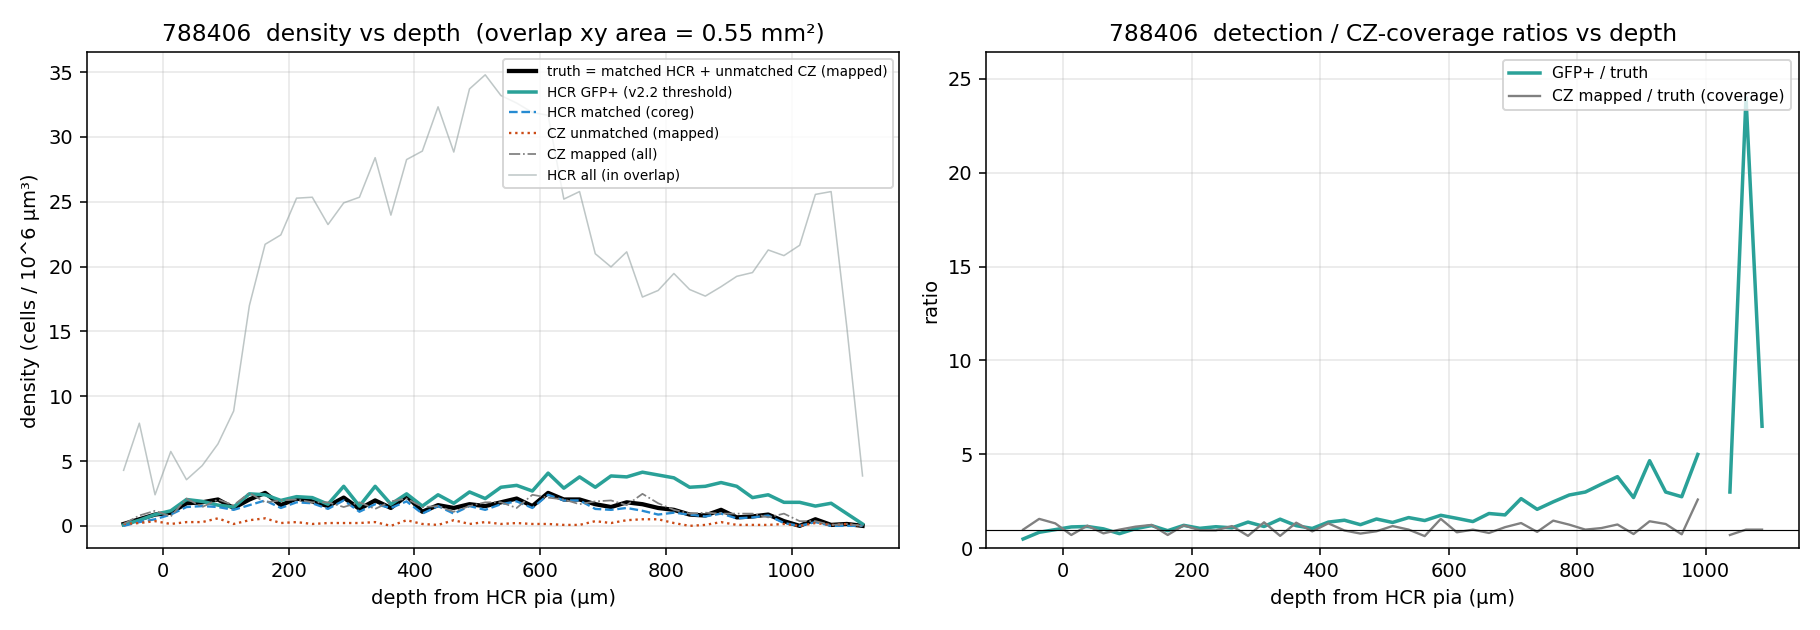

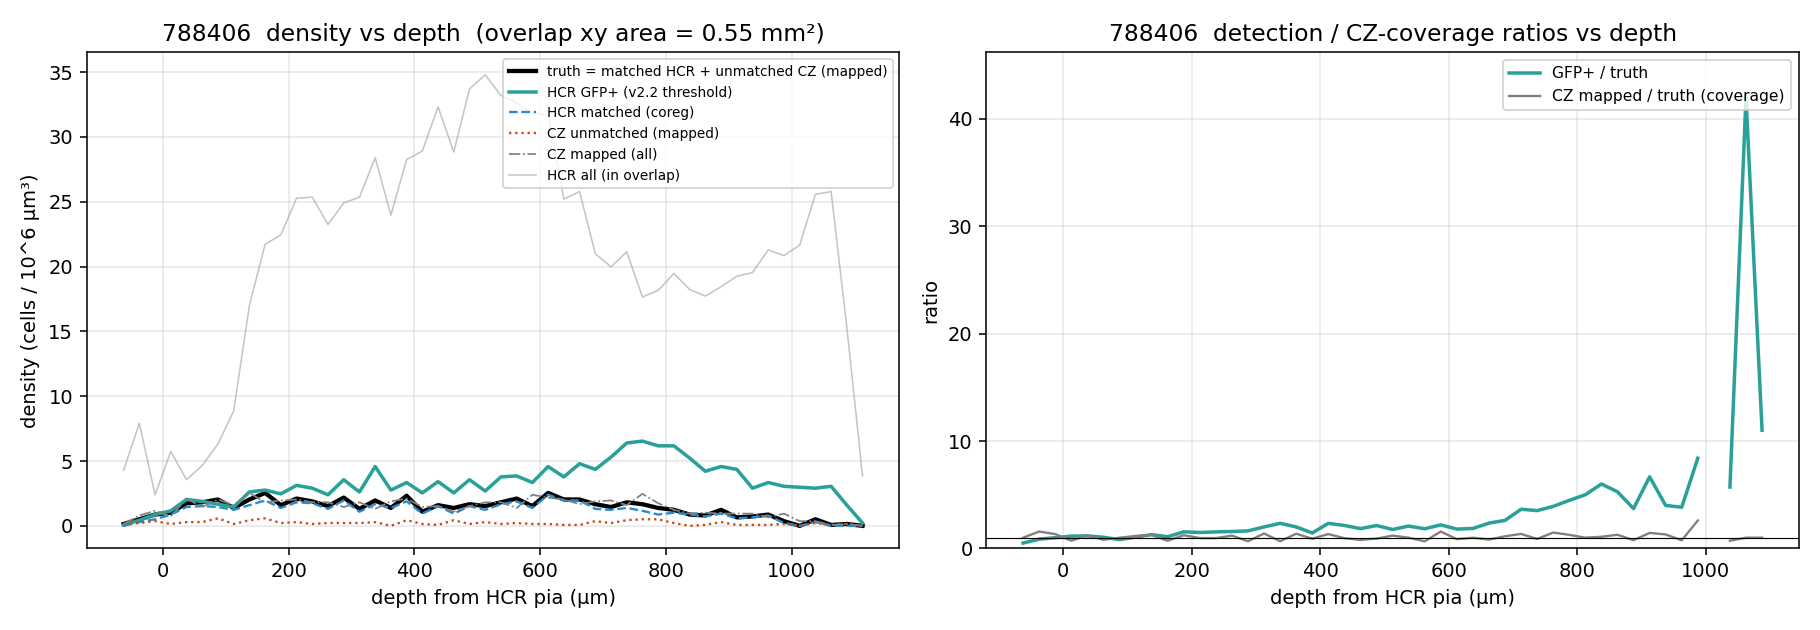

790322  —  strict-GFP+ (top row) vs v2.2-GFP+ (session 07 figure, bottom row)


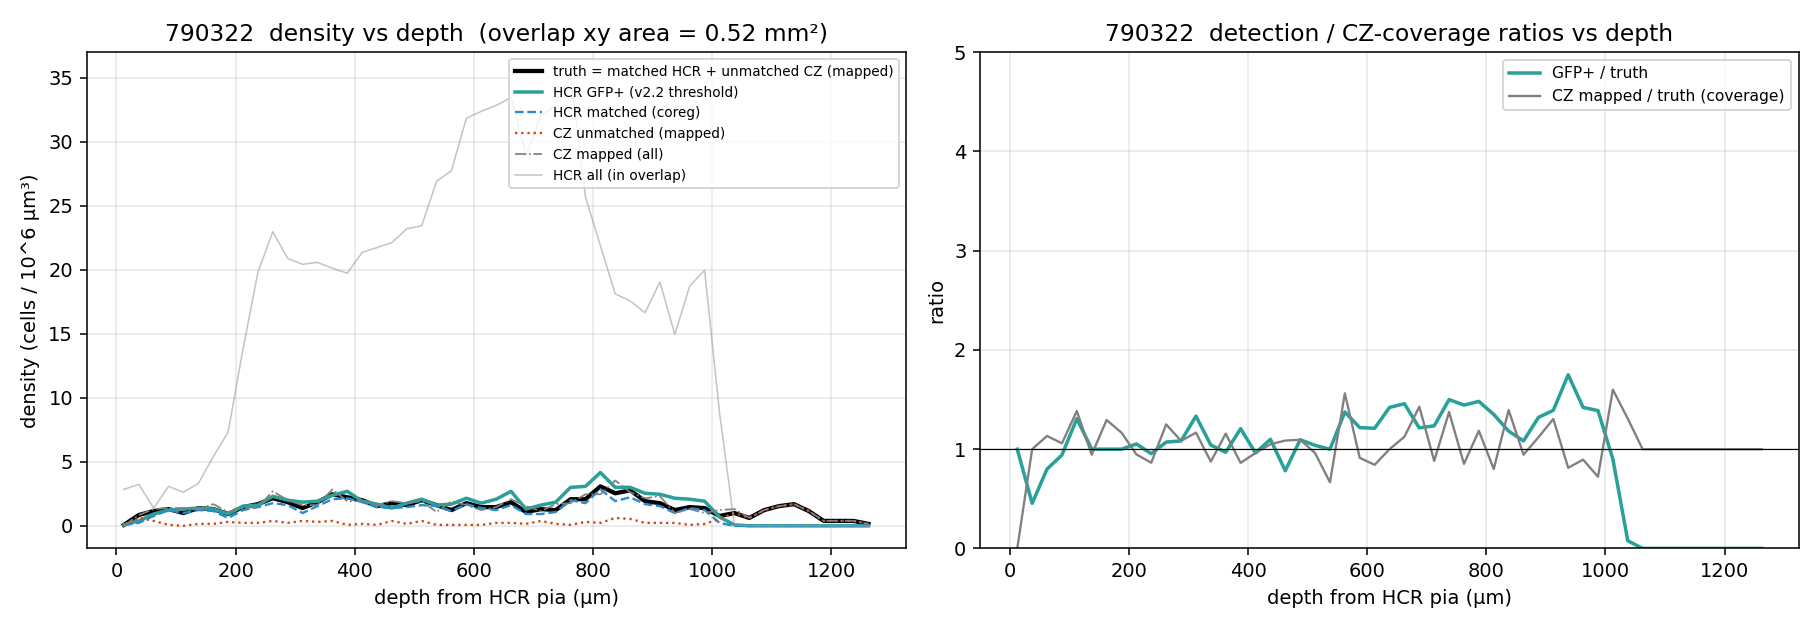

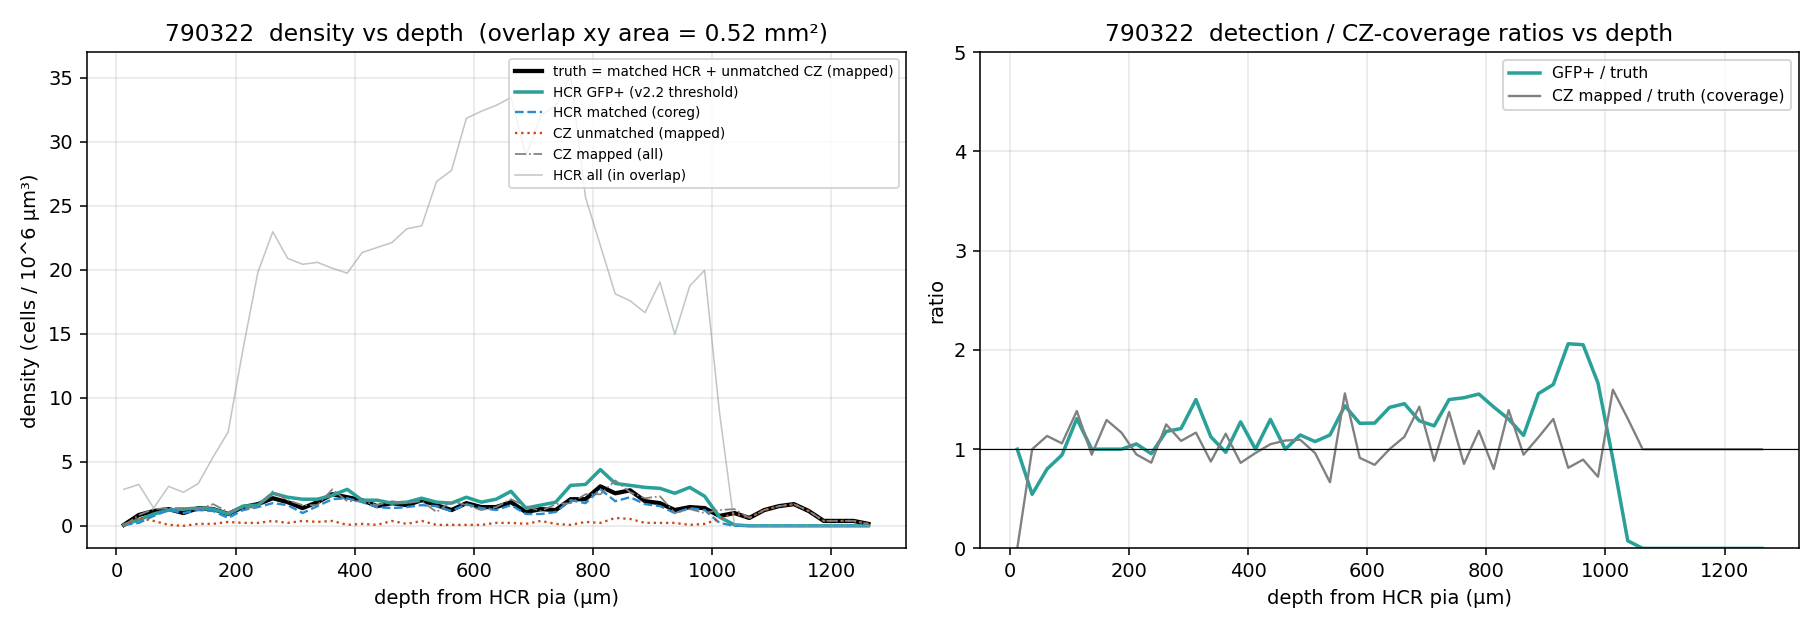

In [5]:
for sid in ['755252', '767018', '782149', '788406', '790322']:
    print(f"{sid}  —  strict-GFP+ (top row) vs v2.2-GFP+ (session 07 figure, bottom row)")
    display(Image(str(SESSION / 'figures' / f'depth_density_strict_{sid}.png')))
    v22_path = Path('/root/capsule/code/sessions/07_scale_failure_diagnosis/figures') / f'depth_density_{sid}.png'
    if v22_path.exists():
        display(Image(str(v22_path)))


**Observation.** The strict cutoff nudges CV down by ~5–17 % and
integrated ratio toward 1 on 2/5 subjects (767018, 790322). But the
underlying bias is still severe: 755252 over-detects 4.75× vs truth
(v2.2: 7.31×), 782149 under-detects at 0.41× (v2.2: 0.46×). No subject
gets per-bin CV near 0.20.

**Conclusion.** The GMM-intersection hypothesis is **falsified**.
Discarding the rightmost component's tail does not make HCR GFP⁺ a
subject- and depth-independent subsample of the truth population.


## 3. Synthetic sanity on the estimators

Stretch a uniform CZ cloud by `(1.77, 1.77, 2.82)` (identity rotation,
no translation). Feed to M1 and M3. Both should recover the scales
within a percent.


In [6]:
synth = R['summary']['synthetic']
print(f"Expected:  sxy=1.77  sz=2.82")
print(f"M1:        sxy={synth['m1']['sxy']:.3f}  sz={synth['m1']['sz']:.3f}")
print(f"M3:        sxy={synth['m3']['sxy']:.3f}  sz={synth['m3']['sz']:.3f}")


Expected:  sxy=1.77  sz=2.82
M1:        sxy=1.804  sz=2.849
M3:        sxy=1.770  sz=2.820


Both estimators are **mathematically sound** on ideal sampling.
The real-data failure is a data-quality failure, not a method bug.


## 4. Scale estimates vs ground truth

Per-subject comparison of M1 (per-axis k-NN ratio, from
`dev_code/local_distance_scale.py`) and M3 (span ratio, this session)
against landmark-Procrustes GT.


In [7]:
scales = [r for r in R['scales'] if 'sxy_gt' in r]
rows = []
for r in scales:
    rows.append({
        'subject': r['subject'],
        'sxy_gt': r['sxy_gt'],  'sz_gt': r['sz_gt'],
        'sxy_m1': r['sxy_m1'],  'sz_m1': r['sz_m1'],
        'sxy_m3': r['sxy_m3'],  'sz_m3': r['sz_m3'],
        'err_sxy_m1%': r['rel_err_sxy_m1'] * 100,
        'err_sz_m1%':  r['rel_err_sz_m1']  * 100,
        'err_sxy_m3%': r['rel_err_sxy_m3'] * 100,
        'err_sz_m3%':  r['rel_err_sz_m3']  * 100,
        'pass5_m1': r['pass5_m1'],  'pass5_m3': r['pass5_m3'],
    })
pd.DataFrame(rows).round(3)


,subject,sxy_gt,sz_gt,sxy_m1,sz_m1,sxy_m3,sz_m3,err_sxy_m1%,err_sz_m1%,err_sxy_m3%,err_sz_m3%,pass5_m1,pass5_m3
0,755252,1.640,2.129,0.886,0.425,4.624,2.078,-45.976,-80.020,181.992,-2.373,False,False
1,767018,1.702,3.583,1.930,1.058,5.645,2.765,13.415,-70.464,231.782,-22.832,False,False
2,782149,1.924,2.926,3.019,0.614,5.860,1.404,56.899,-79.010,204.591,-52.012,False,False
3,788406,1.778,2.820,1.751,0.797,5.729,3.024,-1.484,-71.741,222.276,7.212,False,False
4,790322,1.763,3.042,2.083,0.922,5.856,2.517,18.146,-69.696,232.092,-17.244,False,False


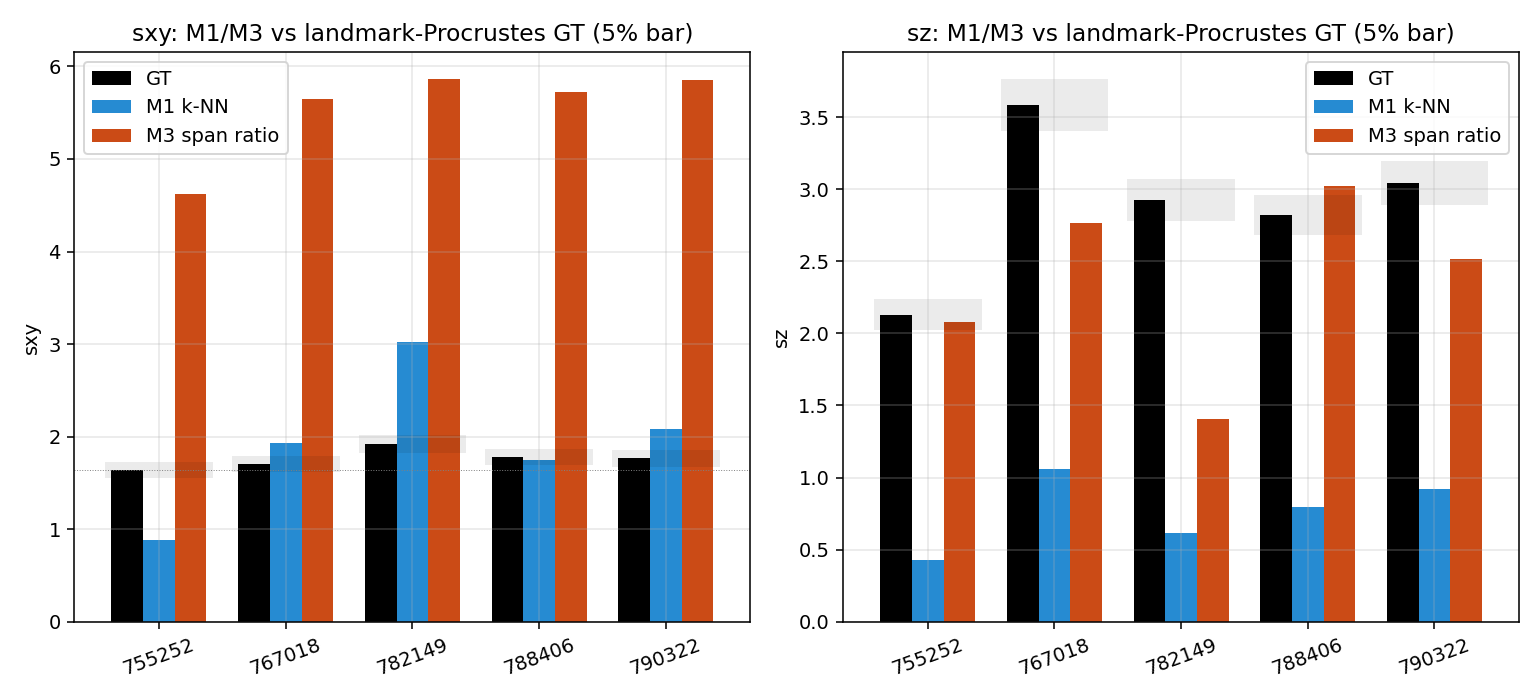

In [8]:
display(Image(str(SESSION / 'figures' / 'scales_comparison.png')))


### M1 failure pattern — sz always low by ~70 %
The strict cutoff retains high-feature cells, which cluster shallower in
depth (see Part C depth profiles). Their z-spread is narrower than the
CZ-mapped cloud's → median nearest-neighbour z-distances on GFP⁺ are too
*small* relative to CZ → `sz = median_hcr_z / median_cz_z < 1` instead
of ~3. **This is detection bias measured as scale.**

`sxy_M1` is closer: 788406 lands at −1.5 % (within 5 %); 767018 at
+13 %; the remaining three are off by 18–57 %.

### M3 failure pattern — sxy always too large by ~3.3×
HCR GFP⁺ covers the full HCR field of view in xy, much wider than the
R1-rotated CZ sub-volume. The span ratio captures **FOV coverage**, not
tissue expansion.

`sz_M3` is surprisingly competitive: 755252 (−2.4 %), 788406 (+7.2 %),
with the other three at 17–52 % error.

### No subject clears both axes on either method
Near-misses on single axes don't recombine — 788406's M1 sxy (within
2 %) pairs with M1 sz (−72 %); 755252's M3 sz (within 3 %) pairs with
M3 sxy (+182 %). There is no stable M1×M3 hybrid that would clear the
5 % bar on both axes for any subject.


## 5. Why 07b fails and what's next

### Root cause (single sentence)
The per-subject, depth-dependent detection bias in HCR GFP⁺ (0.41×–4.75×
integrated at the strict threshold) is larger than the scale ratio we
want to measure (sxy ≈ 1.7×, sz ≈ 3×). Centroid-only estimators are
dominated by the bias.

### What this rules out
- Session 06 k-NN estimator — blocked by the same bias.
- Session 07 anisotropic-ICP — its 6/6 pass was GT-tuned (see
  `memory/project_07_anisotropic_icp_scales.md`), not a validated method.
- Session 07b strict-GFP⁺ + M1/M3 — blocked by the residual bias.

All three are **centroid-feature-only** estimators on the HCR GFP⁺ set.

### Why surface-only (07c) was rejected in planning
- Pia-plane tilt is erased by R1 (which aligns the two planes).
- z-extent from pia to imaging bottom is modality-dependent — CZ and
  HCR stop imaging at different physiological/optical depths for reasons
  unrelated to tissue expansion.

### Next candidate (new session, not implemented here)

**Image-level 488 NCC after R1 + pia-normal alignment.**

The detection bias is baked into the centroid localisation step. Raw
intensity is not: a half-bright spot still contributes its intensity.
Matching CZ GCaMP intensity against HCR 488 intensity directly bypasses
the GFP⁺/GFP⁻ binary.

1. Apply R1 (R, t) to CZ; rotate both so HCR pia-normal → `+z`.
2. In a matched xy ROI, build 1D profiles `I_cz(z)` and `I_hcr_488(z)`.
3. `sz` = argmax `NCC(I_cz(z·sz), I_hcr_488(z))`.
4. For `sxy`, NCC in xy on thin z-slabs at matched depth.

This is substantively different from 07/07b and requires zstack + HCR
488 image re-reading. Deferred to its own session (07c').

### What is reusable from 07b
- `07b_gfp_intersection_threshold.py` — GMM-intersection threshold
  module and the 767022-degenerate warning.
- `07b_scale_from_clean_gfp.py` — depth-density monkey-patch pattern,
  `_patched_loader`, and the M1/M3 driver structure.

The M3 span-ratio formula should **not** be used as a scale estimator
in future work — it's FOV-contaminated.
